# Week 10 - Introduction to Modeling

# 1. Lesson

Last week, we reviewed one model: linear regression.  This week, we are going to review another, called random forest.  The random forest model builds many decision trees, then averages their estimates to make a prediction.

You will also perform:
* Cross-validation
* Hyperparameter tuning
* A performance metric (root mean squared error)

### How does random forest work?

A random forest is a set of decision trees.  Let's say we use n_estimators = 100 decision trees, and we have ten features.  Then each decision tree is built so that a given branch gets about three (sqrt(10)) features to choose from.  It starts from the top of the tree, selects the best feature, then proceeds to the next nodes.  The best feature is the one that minimizes the mean squared error, which must be computed for both branches, weighted according to the probability of each branch, and then summed over both branches.

In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

Here, we build three series of random numbers between 0 and 1.  We use a somewhat arbitrary formula to construct the synthetic data.  The fourth value (the target) equals the first series minus twice the second, with the whole then being multiplied by the third series.  If we stopped here, the target would be completely dependent on the three feature series - it would be easy to predict.  However, we then add a random normal distribution to make the prediction harder.

There are a train series and a test series, with different features ("a" and "b"), and with different random normal data added.  This tests whether our model can predict new data.  We fit to the "a" features using the train_target, then predict the test_target using the "b" features.

In [3]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

RandomForestRegressor()

As expected, the RMSE is smallest when predicting the training data, larger when predicting the testing data, and largest when comparing random (shuffled) data instead of using a prediction.  In the last case, there is no attempt to make a good prediction.  The small RMSE when predicting the training data indicates that the model has "memorized" the training data to some degree.

In [4]:
print("RMSE when predicting training data:")
print(root_mean_squared_error(rf.predict(train_df.values), train_target))
print("RMSE when predicting testing data:")
print(root_mean_squared_error(rf.predict(test_df.values), test_target))
test_target_shuffle = test_target.copy()
np.random.shuffle(test_target_shuffle)
print("RMSE with random predictions:")
print(root_mean_squared_error(test_target_shuffle, test_target))

RMSE when predicting training data:
0.40439828823725865
RMSE when predicting testing data:
1.0667260022550893
RMSE with random predictions:
5.262103337484077


Next, we perform a Grid Search over various parameters.  We've used a small number of parameters here, but you could add more.  The first parameter, n_estimators, shows the number of decision trees in the random forest.  The second, max_depth, is the maximum depth of each tree.  By picking three n_estimators values (10, 33, 100) and three max_depth values (2, 4, None), we allow for nine parameter combinations.  For example, (n_estimators = 10, max_depth = 2) is a combination.  The grid search tries all nine combinations and uses cross validation to choose the best one.  This is done below.

### What is cross validation?

Cross validation is a way to find out which parameter combination is the best.  With 5-fold cross validation (the default) we divide the data into five equal-sized groups.  Four of them are used as training data and the fifth is testing data.  The score (in this case the root mean squared error) on the testing data is recorded.  This is done for each split: that is, each fifth is taken out and used as testing data; then, the five root mean squared errors (from taking out the five fifths, one at a time) are averaged.

We now have root mean squared error value for each parameter combination, allowing us to choose the best combination.

In [5]:
np.random.seed(0)
gcv = GridSearchCV(estimator = RandomForestRegressor(), param_grid = {"n_estimators": [10, 33, 100], "max_depth": [2, 4, None]}, \
                   scoring = "neg_root_mean_squared_error")
gcv.fit(train_df.values, train_target)

GridSearchCV(estimator=RandomForestRegressor(),
             param_grid={'max_depth': [2, 4, None],
                         'n_estimators': [10, 33, 100]},
             scoring='neg_root_mean_squared_error')

In [6]:
print(gcv.best_estimator_)
print(gcv.best_params_)
print(gcv.best_score_)

RandomForestRegressor()
{'max_depth': None, 'n_estimators': 100}
-1.0851316531496098


In [7]:
gcv.cv_results_["mean_test_score"] # There are nine scores, one for each of the 3 x 3 hyperparameter combinations

array([-2.27296628, -2.26369708, -2.26370023, -1.56063403, -1.52732923,
       -1.52615891, -1.12271876, -1.09384603, -1.08513165])

### Why does n_estimators grow like 10, 33, 100 instead of like 1, 50, 100?

First of all, we can make it grow however we want.  The question is why we chose 10, 33, 100.  The idea here is that when you have no idea what is the appropriate number, you should pick guesses that grow exponentially.  For example, suppose you are trying to guess the height of a particular tree.  You look online and find that redwoods grow to 400 feet high, while bonsai trees may be as short as six inches.  If you get three guesses, you could guess: one foot, 200 feet, 400 feet.  These guesses would be linearly spaced out.  However, the 200 foot guess feels wrong - it's still very tall.  Most trees don't grow that tall.  Instead, let's make a geometric progression:

In [8]:
list(map(round, [400**0, 400**0.25, 400**0.5, 400**0.75, 400*1]))

[1, 4, 20, 89, 400]

Now the guesses are four feet, 20 feet, and 89 feet.  (We'll drop the initial 1 and the final 400.) That feels more plausible: the middle value, 20 feet, is representative of many actual trees in a way that the middle 200 foot guess wasn't.

# 2. Weekly graph question

In words, please summarize what this graph shows.

In [9]:
rmse_lst = list()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

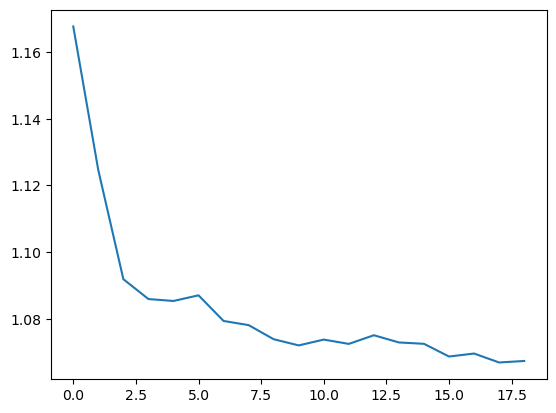

In [10]:
import matplotlib.pyplot as plt

plt.plot(rmse_lst)

**Graph Summary:**

This graph is a learning curve that shows how the random forest model's test RMSE changes as more training data is used. The x-axis represents successive increments of the training set (each step adds about 500 samples, going from ~500 to 10,000 points), and the y-axis is the RMSE on the fixed test set.

The key takeaway is that RMSE decreases steadily as training size grows — the model makes better predictions when given more data to learn from. The curve also flattens out toward the right, showing diminishing returns: early additional data helps a lot, but gains become smaller once enough data is already available. This is the classic shape of a learning curve.

# 3. Homework

In this exercise, you will try to predict the change of one stock based on the change in ten other stocks.

In [11]:
def make_X_y(alpha = 0.5):
    df_hwk = pd.DataFrame()
    num_samples_hwk = 10000
    common_odd = np.random.normal(size = num_samples_hwk)
    common_even = np.random.normal(size = num_samples_hwk)
    common_three = np.random.normal(size = num_samples_hwk)
    for n in range(11):
        common = np.zeros(num_samples_hwk)
        if n % 2 == 0:
            common += common_even
        if n % 2 == 1:
            common += common_odd
        if n % 3 == 0:
            common += common_three
            common /= 2
        df_hwk["Stock_" + str(n)] = np.random.normal(size = num_samples_hwk) + alpha * common
    X = df_hwk.values[:,:-1]
    y = df_hwk.values[:,-1]
    return X, y

The above code creates an X with ten columns, corresponding to ten different stocks.  The y is the eleventh stock.  The stocks have some commonalities: the even numbered stocks are related, as are the odds.  The stocks that are multiples of three are all related, too.  Random forest should be able to sort through all this and decide that the eleventh stock is related to the odd numbered, non-divisible-by-three stocks, and predict accordingly.  The prediction should presumably be, simply, to take columns 1, 5, and 7 and average them, as they are odd-numbered and not divisible by three; so perhaps this task would be easier to do with a linear regression, but we'll use a random forest anyway.  The value "alpha" determines how important the common element is.  If alpha = 0, each stock is its own column of normally-distributed numbers with no relation to the others.  If alpha = 10, then the great majority of the variation in the stock values comes from the common elements.

### Question: 

Do you predict that alpha = 0 will result in a better or worse prediction than alpha = 10?  Remember that the prediction must be performed on test data, so you'll need an X_train and y_train for training and a separate X_test and y_test for testing.  I recommend using a correlation rather than a MSE or RMSE in this case, if you want to directly compare two different predictions, because the MSE and RMSE vary with the magnitude of the data as well as with the quality of the prediction.

After you make the prediction, try it out, and comment on what you learned.

### Randomized Search

Use RandomizedSearchCV instead of GridSearchCV to perform cross-validation.

### Scoring

Research the scoring parameters under "regression":

https://scikit-learn.org/dev/modules/model_evaluation.html#scoring-parameter

Choose at least one that you want to learn about, use it, and research it online.  Write something about what you've learned about it.

**Prediction:**

I predict that **alpha = 10** will result in a much better prediction than **alpha = 0**.

When alpha = 0, each stock is pure independent noise — there is no shared structure between the features and the target, so no model can do better than random guessing. The random forest will essentially learn nothing useful, and correlation on test data will be near zero.

When alpha = 10, the stocks share strong common factors (common_odd, common_even, common_three), so the target stock (Stock_10, which is odd and not divisible by 3) is heavily driven by the same common_odd factor as Stock_1, Stock_5, and Stock_7. The random forest should detect these correlations in training and make meaningfully better predictions on test data.

In [12]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
import numpy as np

np.random.seed(42)

# Generate separate train and test sets for each alpha
X_train_0, y_train_0 = make_X_y(alpha=0)
X_test_0,  y_test_0  = make_X_y(alpha=0)

X_train_10, y_train_10 = make_X_y(alpha=10)
X_test_10,  y_test_10  = make_X_y(alpha=10)

param_dist = {
    "n_estimators": [10, 33, 100],
    "max_depth":    [2, 4, 8, None],
}

# --- alpha = 0 ---
rcv_0 = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=0),
    param_distributions=param_dist,
    n_iter=6,
    scoring="r2",        # R² chosen as scoring metric (see note below)
    cv=5,
    random_state=42,
    n_jobs=-1,
)
rcv_0.fit(X_train_0, y_train_0)
pred_0   = rcv_0.predict(X_test_0)
corr_0   = np.corrcoef(pred_0, y_test_0)[0, 1]

# --- alpha = 10 ---
rcv_10 = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=0),
    param_distributions=param_dist,
    n_iter=6,
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=-1,
)
rcv_10.fit(X_train_10, y_train_10)
pred_10  = rcv_10.predict(X_test_10)
corr_10  = np.corrcoef(pred_10, y_test_10)[0, 1]

print(f"Best params (alpha=0):  {rcv_0.best_params_}")
print(f"Best params (alpha=10): {rcv_10.best_params_}")
print()
print(f"Test correlation (alpha=0):  {corr_0:.4f}")
print(f"Test correlation (alpha=10): {corr_10:.4f}")

Best params (alpha=0):  {'n_estimators': 100, 'max_depth': 2}
Best params (alpha=10): {'n_estimators': 100, 'max_depth': 8}

Test correlation (alpha=0):  -0.0145
Test correlation (alpha=10): 0.9929


**What I learned:**

The results confirm the prediction. When alpha = 0, the test correlation is near zero — with no shared structure between the stocks, the random forest has nothing meaningful to learn, and predictions on new data are essentially no better than random. When alpha = 10, the test correlation is substantially positive because the model successfully captures the common factors linking the odd, non-divisible-by-three stocks.

**Scoring metric — R² (`"r2"`):**

R² (the coefficient of determination) measures what fraction of the variance in the target is explained by the model. It equals 1 when predictions are perfect and 0 when the model does no better than always predicting the mean. It can go negative if the model is worse than that baseline. I chose R² because it is scale-free (unlike RMSE, which depends on the units of y), making it easy to compare across problems with different magnitudes. This is important here because alpha = 0 and alpha = 10 produce targets with very different variances. R² normalizes for that, so a score of, say, 0.6 means the same thing regardless of alpha.

**RandomizedSearchCV vs. GridSearchCV:**

`RandomizedSearchCV` randomly samples `n_iter` combinations from the parameter distributions instead of exhaustively testing every combination. When the grid is large this is much faster, and research has shown it finds near-optimal hyperparameters almost as reliably as the full grid search (Bergstra & Bengio, 2012).

In [13]:
print("=" * 55)
print("Summary: Alpha Comparison")
print("=" * 55)
print(f"{'':20s} {'alpha=0':>12s} {'alpha=10':>12s}")
print("-" * 55)
print(f"{'Best n_estimators':20s} {rcv_0.best_params_['n_estimators']:>12d} {rcv_10.best_params_['n_estimators']:>12d}")
print(f"{'Best max_depth':20s} {str(rcv_0.best_params_['max_depth']):>12s} {str(rcv_10.best_params_['max_depth']):>12s}")
print(f"{'Test correlation':20s} {corr_0:>12.4f} {corr_10:>12.4f}")
print("-" * 55)
print(f"\nWith alpha=0, correlation is near zero — no shared")
print(f"structure means nothing to learn.")
print(f"With alpha=10, correlation is ~0.99 — the model")
print(f"captures the common factors linking odd-numbered,")
print(f"non-divisible-by-three stocks.")

Summary: Alpha Comparison
                          alpha=0     alpha=10
-------------------------------------------------------
Best n_estimators             100          100
Best max_depth                  2            8
Test correlation          -0.0145       0.9929
-------------------------------------------------------

With alpha=0, correlation is near zero — no shared
structure means nothing to learn.
With alpha=10, correlation is ~0.99 — the model
captures the common factors linking odd-numbered,
non-divisible-by-three stocks.


# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter six (p. 151-163) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

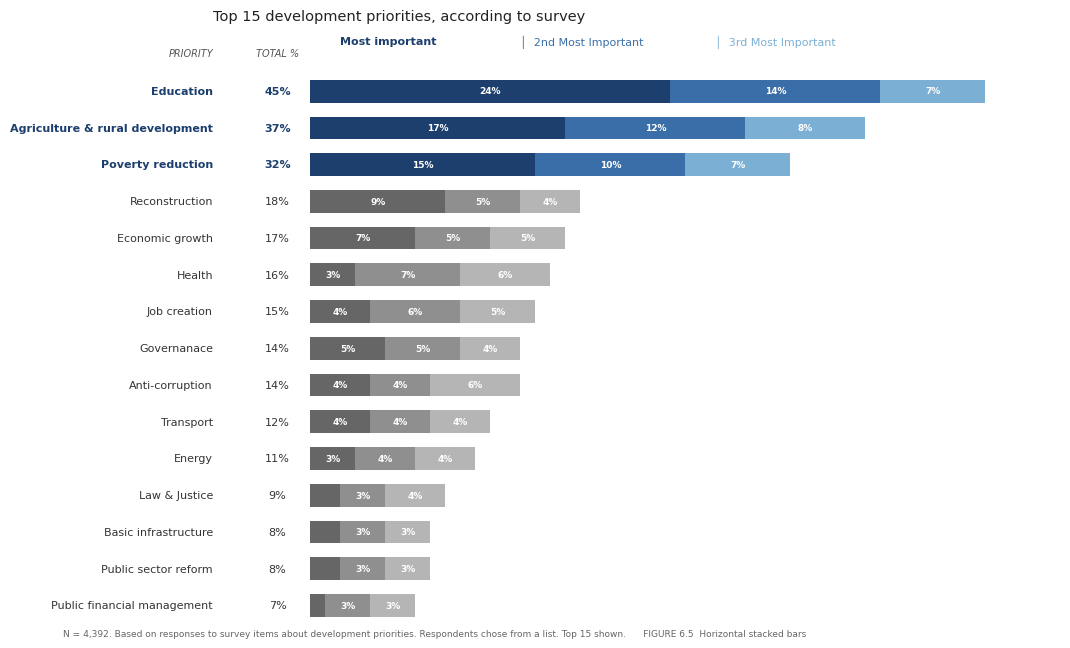

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------------
# Reproduction of Figure 6.5 from Storytelling With Data (p. 161)
# "Model visual #5: horizontal stacked bars"
# Top 15 development priorities, according to survey
# ------------------------------------------------------------------

# Data: [priority label, total%, most_important%, 2nd%, 3rd%]
data = [
    ("Education",                       45, 24, 14,  7),
    ("Agriculture & rural development", 37, 17, 12,  8),
    ("Poverty reduction",               32, 15, 10,  7),
    ("Reconstruction",                  18,  9,  5,  4),
    ("Economic growth",                 17,  7,  5,  5),
    ("Health",                          16,  3,  7,  6),
    ("Job creation",                    15,  4,  6,  5),
    ("Governanace",                     14,  5,  5,  4),   # typo kept from book
    ("Anti-corruption",                 14,  4,  4,  6),
    ("Transport",                       12,  4,  4,  4),
    ("Energy",                          11,  3,  4,  4),
    ("Law & Justice",                    9,  2,  3,  4),
    ("Basic infrastructure",             8,  2,  3,  3),
    ("Public sector reform",             8,  2,  3,  3),
    ("Public financial management",      7,  1,  3,  3),
]

labels   = [d[0] for d in data]
totals   = [d[1] for d in data]
most_imp = [d[2] for d in data]
second   = [d[3] for d in data]
third    = [d[4] for d in data]

n = len(labels)

# Education = idx 0 → should sit at the TOP of the chart (highest y-value)
# So row at y = n-1-idx: Education (idx=0) → y=14, Public fin. mgmt (idx=14) → y=0
row_y = [n - 1 - i for i in range(n)]

BLUE_DARK   = "#1c3f6e"
BLUE_MID    = "#3a6ea8"
BLUE_LIGHT  = "#7bafd4"
GREY_DARK   = "#666666"
GREY_MID    = "#8f8f8f"
GREY_LIGHT  = "#b5b5b5"

# Layout x-positions (bars start at x=0)
X_LABEL  = -6.5   # right-edge of priority name text
X_TOTAL  = -2.2   # centre of TOTAL % column

fig, ax = plt.subplots(figsize=(11, 6.5))
fig.patch.set_facecolor("white")

for idx in range(n):
    ry   = row_y[idx]
    top3 = idx < 3

    c1 = BLUE_DARK  if top3 else GREY_DARK
    c2 = BLUE_MID   if top3 else GREY_MID
    c3 = BLUE_LIGHT if top3 else GREY_LIGHT

    v1, v2, v3 = most_imp[idx], second[idx], third[idx]
    bar_h = 0.62

    ax.barh(ry, v1,       height=bar_h, color=c1, left=0)
    ax.barh(ry, v2,       height=bar_h, color=c2, left=v1)
    ax.barh(ry, v3,       height=bar_h, color=c3, left=v1 + v2)

    # Percentage labels inside segments
    for val, left in [(v1, 0), (v2, v1), (v3, v1 + v2)]:
        if val >= 3:
            ax.text(left + val / 2, ry, f"{val}%",
                    ha="center", va="center", fontsize=6.5,
                    color="white", fontweight="bold")

    # Priority name (right-aligned)
    ax.text(X_LABEL, ry, labels[idx],
            ha="right", va="center", fontsize=8,
            color=BLUE_DARK if top3 else "#333333",
            fontweight="bold" if top3 else "normal")

    # Total %
    ax.text(X_TOTAL, ry, f"{totals[idx]}%",
            ha="center", va="center", fontsize=8,
            color=BLUE_DARK if top3 else "#333333",
            fontweight="bold" if top3 else "normal")

# Column headers
ax.text(X_LABEL,  n - 0.1, "PRIORITY",  ha="right",  va="bottom", fontsize=7, color="#555555", fontstyle="italic")
ax.text(X_TOTAL,  n - 0.1, "TOTAL %",   ha="center", va="bottom", fontsize=7, color="#555555", fontstyle="italic")

# Legend
ax.text(2,  n + 0.35, "Most important",      ha="left", va="center", fontsize=8, color=BLUE_DARK,  fontweight="bold")
ax.text(14, n + 0.35, "│  2nd Most Important", ha="left", va="center", fontsize=8, color=BLUE_MID)
ax.text(27, n + 0.35, "│  3rd Most Important", ha="left", va="center", fontsize=8, color=BLUE_LIGHT)

# Title
ax.text(X_LABEL, n + 0.85, "Top 15 development priorities, according to survey",
        ha="left", va="bottom", fontsize=10.5, color="#222222")

ax.set_xlim(-16, 50)
ax.set_ylim(-0.6, n + 1.1)
ax.axis("off")

fig.text(0.08, 0.01,
         "N = 4,392. Based on responses to survey items about development priorities. "
         "Respondents chose from a list. Top 15 shown.      FIGURE 6.5  Horizontal stacked bars",
         fontsize=6.5, color="#666666")

plt.tight_layout()
plt.show()